# SAFE — Validación del Sistema

**Parte A:** Métricas con 1000 features reales (500 auténticas + 500 falsas)
**Parte B:** Evidencia visual con 20 muestras lado a lado

---
## Parte A: Pipeline de Validación + Métricas

In [26]:
import cv2, numpy as np, random
from pathlib import Path
import matplotlib.pyplot as plt

random.seed(42); np.random.seed(42)
IMG_SIZE = 96

def pad_96x96(img):
    """Transforma crop a 96×96 con padding, preserva aspect ratio."""
    h, w = img.shape[:2]
    scale = IMG_SIZE / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (nw, nh))
    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    yo, xo = (IMG_SIZE - nh) // 2, (IMG_SIZE - nw) // 2
    canvas[yo:yo+nh, xo:xo+nw] = resized.astype(np.float32) / 255.0
    return canvas

# Cargar modelo ONNX (el mismo que corre en la RPi)
net = cv2.dnn.readNetFromONNX('../Models_rpi/siamese_embedding.onnx')
print("ONNX cargado")

# Embedding de referencia
ref_img = cv2.imread('../Models_rpi/siamese_reference.png', cv2.IMREAD_GRAYSCALE)
ref = pad_96x96(ref_img)
net.setInput(ref.reshape(1, IMG_SIZE, IMG_SIZE, 1))
emb_ref = net.forward()[0]
emb_ref = emb_ref / (np.linalg.norm(emb_ref) + 1e-8)
print(f"Referencia OK (norm={np.linalg.norm(emb_ref):.4f})")

def compute_sim(img):
    """Calcula similitud L1 contra la referencia."""
    crop = pad_96x96(img)
    net.setInput(crop.reshape(1, IMG_SIZE, IMG_SIZE, 1))
    emb = net.forward()[0]
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return 1 - np.mean(np.abs(emb_ref - emb))

print("Pipeline listo: padding 96×96 → ONNX → L2-norm → L1-sim")

ONNX cargado
Referencia OK (norm=1.0000)
Pipeline listo: padding 96×96 → ONNX → L2-norm → L1-sim


In [27]:
# Cargar features auténticas (aleatorio)
auth_paths = sorted((Path('../Data/Validacion_data/autenticos').glob('*.png')))
fake_paths = sorted((Path('../Data/Validacion_data/falsos').glob('*.jpg')))
random.shuffle(auth_paths); random.shuffle(fake_paths)

N = 100
print(f"Procesando {N} autenticas + {N} falsas...")

auth_sims = []
for p in auth_paths[:N]:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        auth_sims.append(compute_sim(img))

fake_sims = []
for p in fake_paths[:N]:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        fake_sims.append(compute_sim(img))

auth_sims = np.array(auth_sims)
fake_sims = np.array(fake_sims)
print(f"Auth: {len(auth_sims)} crops — sim mean={auth_sims.mean():.4f} ± {auth_sims.std():.4f}")
print(f"Fake: {len(fake_sims)} crops — sim mean={fake_sims.mean():.4f} ± {fake_sims.std():.4f}")
print(f"GAP = {auth_sims.mean() - fake_sims.mean():.4f}")

Procesando 100 autenticas + 100 falsas...
Auth: 100 crops — sim mean=0.9638 ± 0.0208
Fake: 100 crops — sim mean=0.8662 ± 0.0054
GAP = 0.0976


In [28]:
# Metricas con threshold = 0.88
THR = 0.88
tp = np.sum(auth_sims >= THR); fn = np.sum(auth_sims < THR)
fp = np.sum(fake_sims >= THR); tn = np.sum(fake_sims < THR)

acc = (tp+tn)/(tp+tn+fp+fn)
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec = tp/(tp+fn) if (tp+fn)>0 else 0
f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0

print("="*50)
print("  RESULTADOS DE VALIDACIÓN")
print(f"  Muestras: {len(auth_sims)} auténticas + {len(fake_sims)} falsas")
print(f"  Umbral:   {THR}")
print("="*50)
print(f"  Accuracy:     {acc*100:.2f}%")
print(f"  Precision:    {prec*100:.2f}%")
print(f"  Recall:       {rec*100:.2f}%")
print(f"  F1-Score:     {f1*100:.2f}%")
print(f"  GAP:          {auth_sims.mean()-fake_sims.mean():.4f}")
print()
print(f"  VP (OK real):       {tp}")
print(f"  FP (falso dijo OK): {fp}")
print(f"  VN (OK falso):      {tn}")
print(f"  FN (real dijo KO):  {fn}")
print("="*50)

  RESULTADOS DE VALIDACIÓN
  Muestras: 100 auténticas + 100 falsas
  Umbral:   0.88
  Accuracy:     98.00%
  Precision:    96.15%
  Recall:       100.00%
  F1-Score:     98.04%
  GAP:          0.0976

  VP (OK real):       100
  FP (falso dijo OK): 4
  VN (OK falso):      96
  FN (real dijo KO):  0


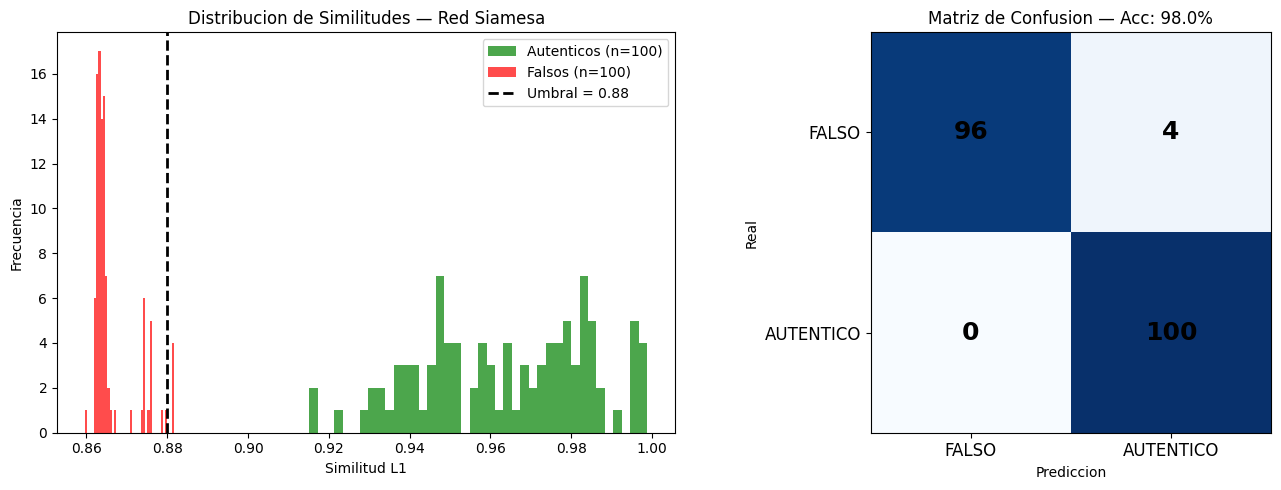

In [29]:
# Graficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + boxplot
axes[0].hist(auth_sims, bins=40, alpha=0.7, color='green', label=f'Autenticos (n={len(auth_sims)})')
axes[0].hist(fake_sims, bins=40, alpha=0.7, color='red', label=f'Falsos (n={len(fake_sims)})')
axes[0].axvline(THR, color='black', linestyle='--', linewidth=2, label=f'Umbral = {THR}')
axes[0].set_xlabel('Similitud L1'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de Similitudes — Red Siamesa')
axes[0].legend()

# Matriz de confusion
cm = np.array([[tn, fp], [fn, tp]])
axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['FALSO', 'AUTENTICO'], fontsize=12)
axes[1].set_yticklabels(['FALSO', 'AUTENTICO'], fontsize=12)
axes[1].set_xlabel('Prediccion'); axes[1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=18, fontweight='bold')
axes[1].set_title(f'Matriz de Confusion — Acc: {acc*100:.1f}%')
plt.tight_layout(); plt.show()

---
## Transformación: Original → 96×96 (Padding)

Cada feature se redimensiona a 96×96 preservando su aspect ratio.
Las bandas negras son padding (no se estira la imagen).

Las imágenes están guardadas en `rpi_deployment/imagenes_de_test/`

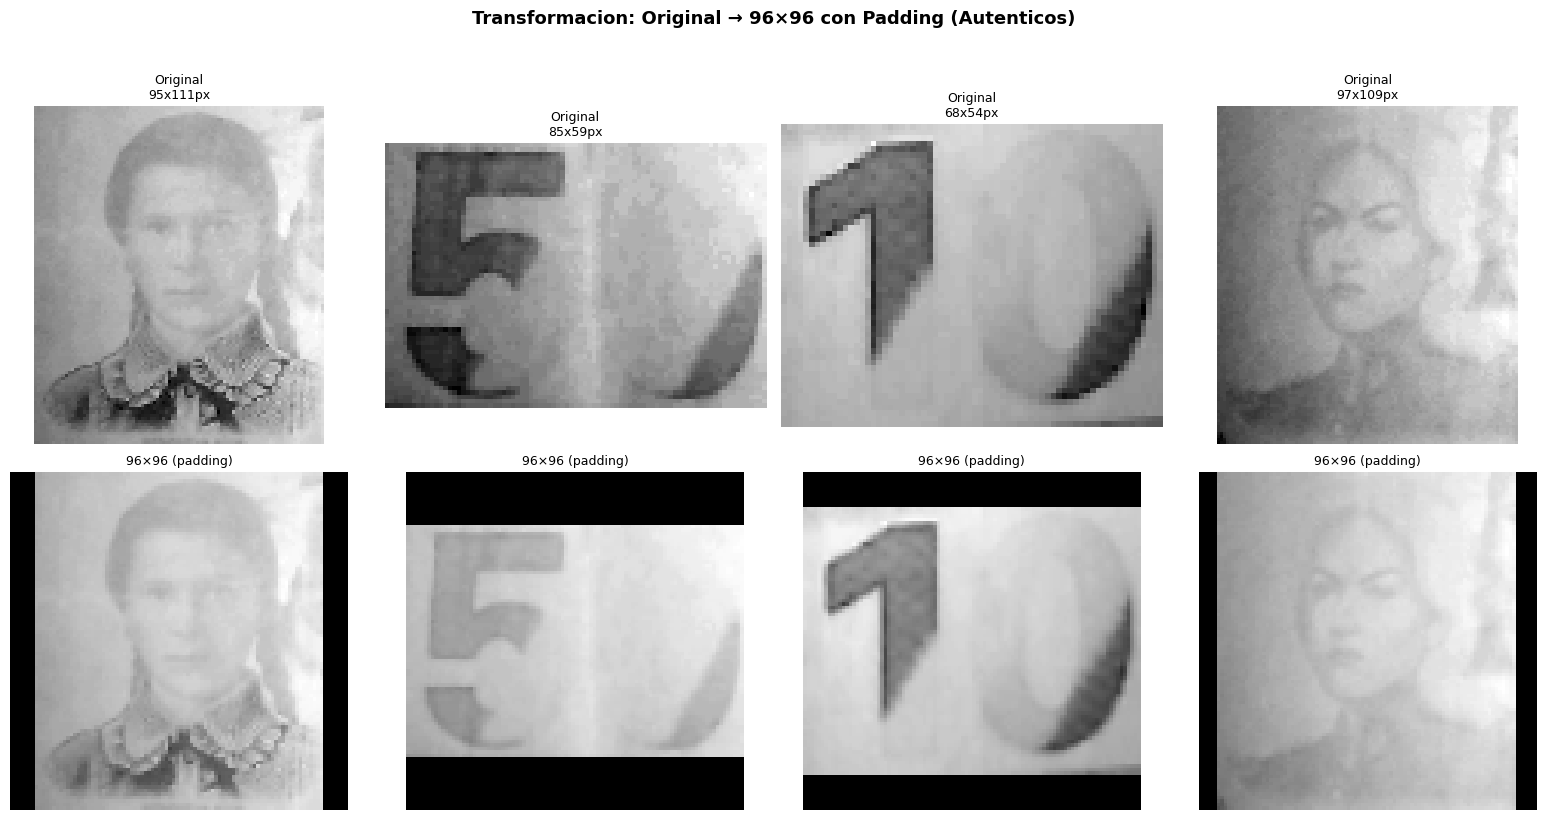

Carpeta: ../rpi_deployment/imagenes_de_test/
  autenticos_96x96: 20 imagenes
  autenticos_original: 20 imagenes
  falsos_96x96: 20 imagenes
  falsos_original: 20 imagenes


In [30]:
from pathlib import Path
import cv2

test_dir = Path('../rpi_deployment/imagenes_de_test')

def show_transformation(n=4):
    """Muestra N imagenes originales vs su version 96x96."""
    orig_imgs = sorted((test_dir / 'autenticos_original').glob('*.png'))[:n]
    pad_imgs  = sorted((test_dir / 'autenticos_96x96').glob('*.png'))[:n]
    
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    
    for i, (orig, pad) in enumerate(zip(orig_imgs, pad_imgs)):
        original = cv2.imread(str(orig), cv2.IMREAD_GRAYSCALE)
        padded   = cv2.imread(str(pad), cv2.IMREAD_GRAYSCALE)
        
        axes[0, i].imshow(original, cmap='gray')
        h, w = original.shape[:2]
        axes[0, i].set_title(f'Original\n{w}x{h}px', fontsize=9)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(padded, cmap='gray')
        axes[1, i].set_title(f'96×96 (padding)', fontsize=9)
        axes[1, i].axis('off')
    
    plt.suptitle('Transformacion: Original → 96×96 con Padding (Autenticos)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

show_transformation(4)
print(f"Carpeta: {test_dir}/")
for d in sorted(test_dir.iterdir()):
    if d.is_dir():
        print(f"  {d.name}: {len(list(d.glob('*.png')))} imagenes")

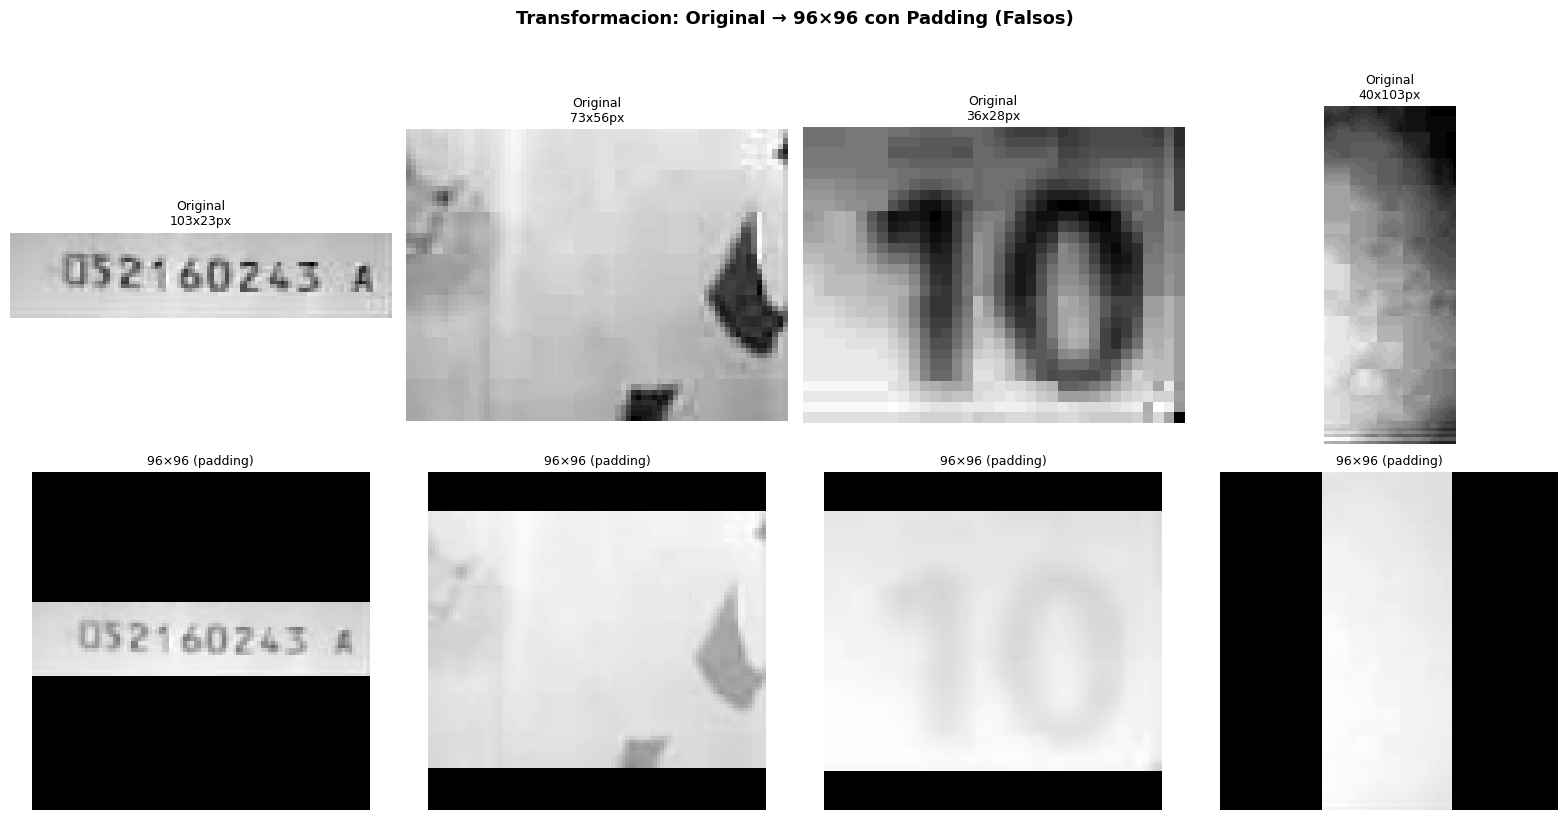

In [31]:
# Mostrar tambien falsos transformados
test_dir = Path('../rpi_deployment/imagenes_de_test')

orig_imgs = sorted((test_dir / 'falsos_original').glob('*.png'))[:4]
pad_imgs  = sorted((test_dir / 'falsos_96x96').glob('*.png'))[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (orig, pad) in enumerate(zip(orig_imgs, pad_imgs)):
    original = cv2.imread(str(orig), cv2.IMREAD_GRAYSCALE)
    padded   = cv2.imread(str(pad), cv2.IMREAD_GRAYSCALE)
    h, w = original.shape[:2]
    axes[0, i].imshow(original, cmap='gray')
    axes[0, i].set_title(f'Original\n{w}x{h}px', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(padded, cmap='gray')
    axes[1, i].set_title(f'96×96 (padding)', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Transformacion: Original → 96×96 con Padding (Falsos)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Parte B: Evidencia Visual — 20 Muestras

10 crops auténticos vs 10 crops falsos lado a lado con su similitud calculada.
Verde = sim ≥ 0.88 (AUTÉNTICO). Rojo = sim < 0.88 (FALSO).

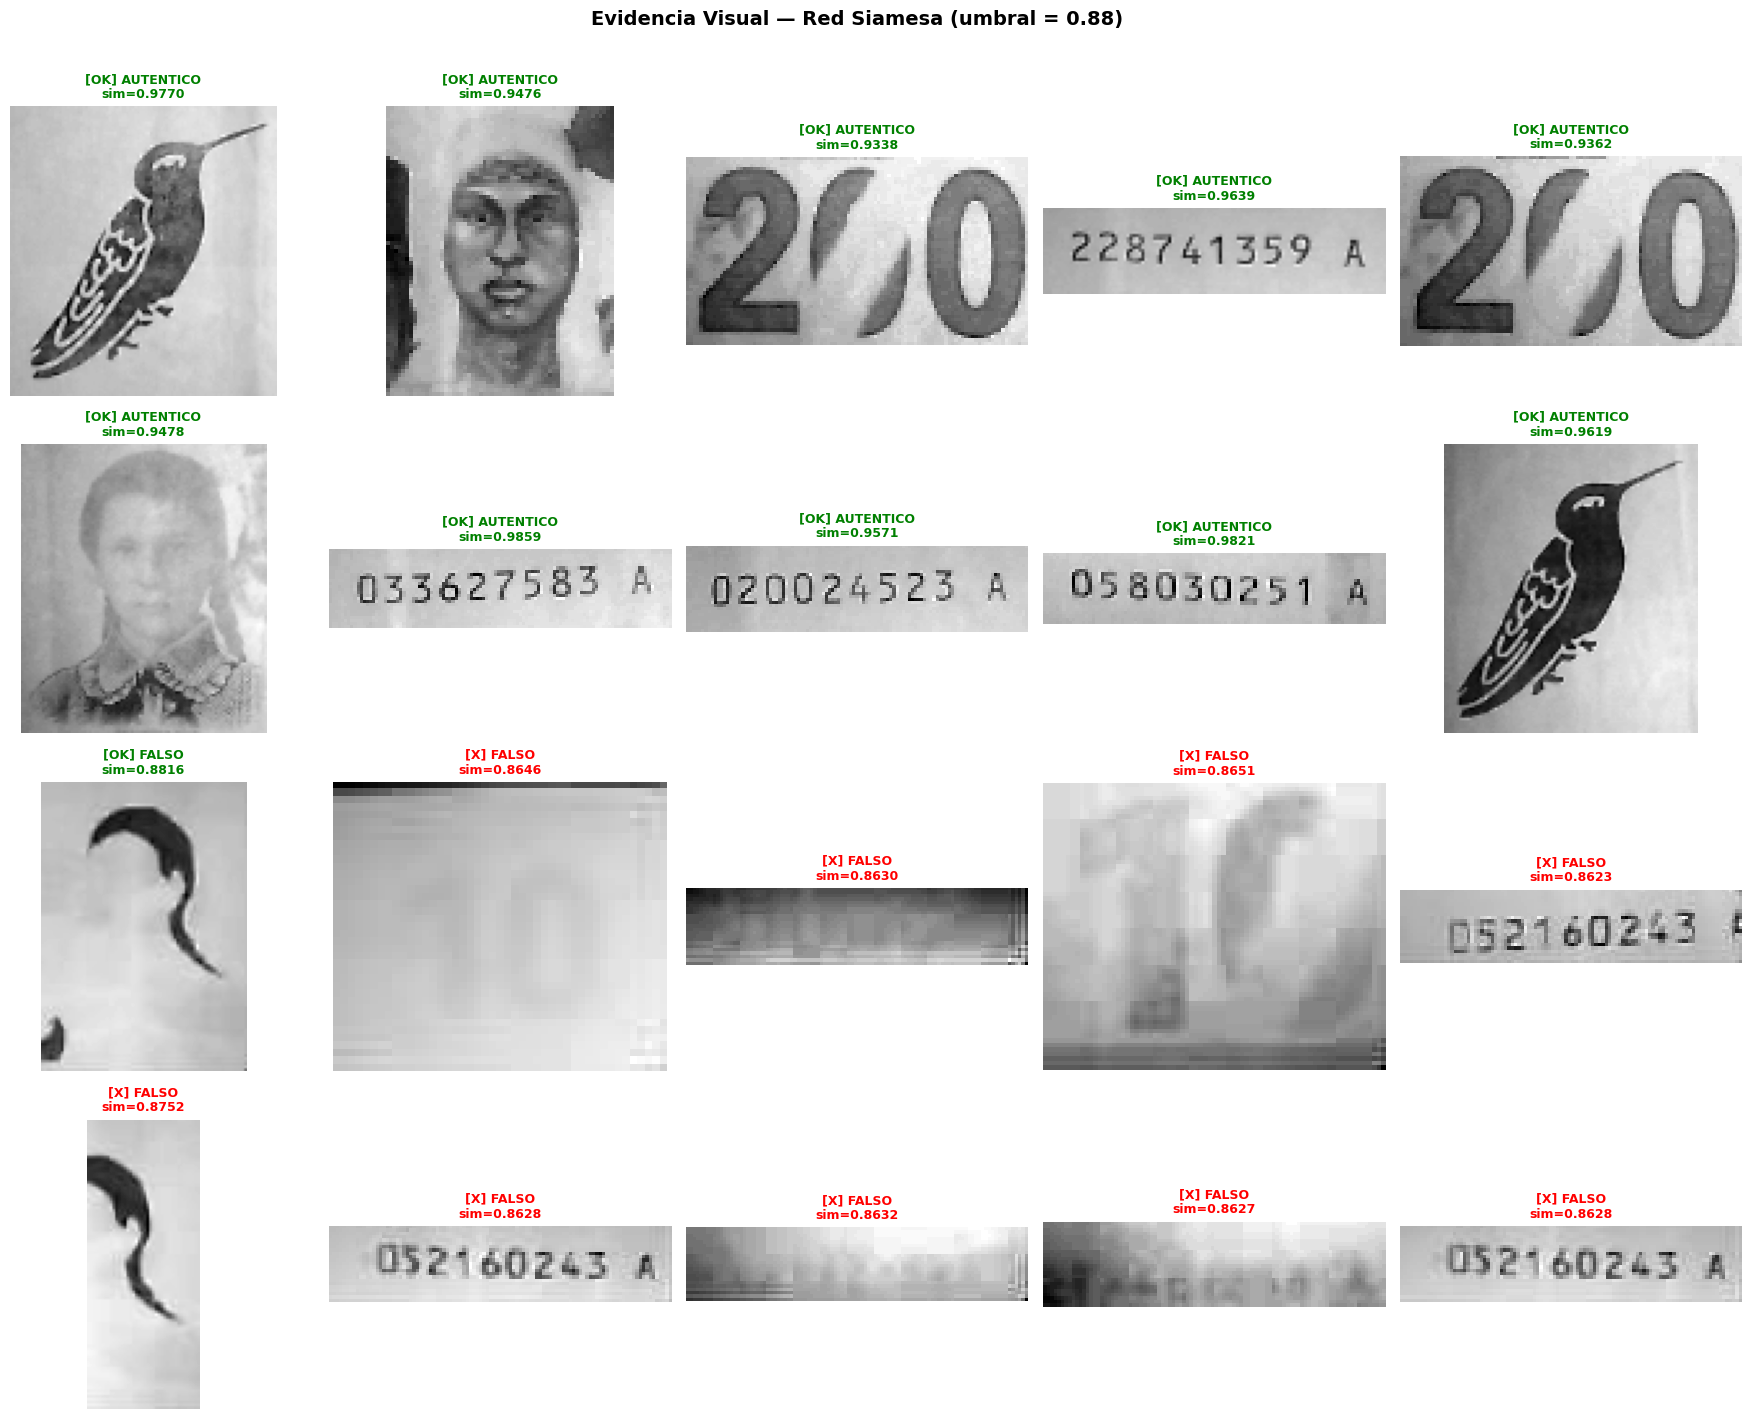

In [32]:
# Seleccionar 10 auth + 10 fake
n_show = 10
show_auth = random.sample(auth_paths, n_show)
show_fake = random.sample(fake_paths, n_show)

fig, axes = plt.subplots(4, 5, figsize=(18, 14))

for i, (path, is_auth) in enumerate(
    [(p, True) for p in show_auth] + [(p, False) for p in show_fake]
):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    sim = compute_sim(img)
    
    # Mostrar imagen original (no el canvas 96x96)
    ax.imshow(img, cmap='gray')
    
    label = 'AUTENTICO' if is_auth else 'FALSO'
    ok = sim >= THR
    color = 'green' if ok else 'red'
    status = 'OK' if ok else 'X'
    
    ax.set_title(f'[{status}] {label}\nsim={sim:.4f}', color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Evidencia Visual — Red Siamesa (umbral = {THR})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# Resumen de la Parte B
print(f"Autenticos — similitudes: {[f'{compute_sim(cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)):.3f}' for p in show_auth]}")
print(f"Falsos     — similitudes: {[f'{compute_sim(cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)):.3f}' for p in show_fake]}")
print(f"\nUmbral: {THR} | Gap medio: {auth_sims.mean()-fake_sims.mean():.3f}")

Autenticos — similitudes: ['0.977', '0.948', '0.934', '0.964', '0.936', '0.948', '0.986', '0.957', '0.982', '0.962']
Falsos     — similitudes: ['0.882', '0.865', '0.863', '0.865', '0.862', '0.875', '0.863', '0.863', '0.863', '0.863']

Umbral: 0.88 | Gap medio: 0.098


---
## Validación con Imágenes Procesadas (96×96)

Usa las imágenes ya transformadas de `rpi_deployment/imagenes_de_test/`
para validar el modelo directamente sin re-procesar.

In [34]:
import cv2, numpy as np
from pathlib import Path

IMG_SIZE = 96
test_dir = Path('../rpi_deployment/imagenes_de_test')

# Cargar modelo si no esta cargado (celda A)
if 'net' not in dir():
    net = cv2.dnn.readNetFromONNX('../Models_rpi/siamese_embedding.onnx')
    ref_img = cv2.imread('../Models_rpi/siamese_reference.png', cv2.IMREAD_GRAYSCALE)
    h,w = ref_img.shape[:2]; s = IMG_SIZE/max(h,w)
    nh,nw = int(h*s), int(w*s)
    canvas = np.zeros((96,96), dtype=np.float32)
    yo,xo = (96-nh)//2, (96-nw)//2
    canvas[yo:yo+nh, xo:xo+nw] = cv2.resize(ref_img,(nw,nh)).astype(np.float32)/255.0
    net.setInput(canvas.reshape(1,96,96,1))
    emb_ref = net.forward()[0]
    emb_ref = emb_ref / (np.linalg.norm(emb_ref) + 1e-8)

def classify_96x96(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = img.astype(np.float32) / 255.0
    net.setInput(img.reshape(1, 96, 96, 1))
    emb = net.forward()[0]
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return 1 - np.mean(np.abs(emb_ref - emb))

THR = 0.88
print(f'Umbral: {THR}\n')

for label, folder in [('AUTENTICOS', 'autenticos_96x96'), ('FALSOS', 'falsos_96x96')]:
    print(f'=== {label} ===')
    files = sorted((test_dir / folder).glob('*.png'))
    correct = 0
    for f in files:
        sim = classify_96x96(f)
        if sim is not None:
            ok = (sim >= THR) if label == 'AUTENTICOS' else (sim < THR)
            correct += ok
            status = 'OK' if ok else 'X'
            print(f'  [{status}] {f.name}: sim={sim:.4f}')
    print(f'  Resultado: {correct}/{len(files)} correctos ({100*correct/len(files):.1f}%)\n')

Umbral: 0.88

=== AUTENTICOS ===
  [OK] auth_000_96x96.png: sim=0.9484
  [OK] auth_001_96x96.png: sim=0.9510
  [OK] auth_002_96x96.png: sim=0.9480
  [OK] auth_003_96x96.png: sim=0.9305
  [OK] auth_004_96x96.png: sim=0.9802
  [OK] auth_005_96x96.png: sim=0.9218
  [OK] auth_006_96x96.png: sim=0.9790
  [OK] auth_007_96x96.png: sim=0.9879
  [OK] auth_008_96x96.png: sim=0.9961
  [OK] auth_009_96x96.png: sim=0.9549
  [OK] auth_010_96x96.png: sim=0.9790
  [OK] auth_011_96x96.png: sim=0.9783
  [OK] auth_012_96x96.png: sim=0.9696
  [OK] auth_013_96x96.png: sim=0.9580
  [OK] auth_014_96x96.png: sim=0.9165
  [OK] auth_015_96x96.png: sim=0.9859
  [OK] auth_016_96x96.png: sim=0.9584
  [OK] auth_017_96x96.png: sim=0.9678
  [OK] auth_018_96x96.png: sim=0.9379
  [OK] auth_019_96x96.png: sim=0.9800
  Resultado: 20/20 correctos (100.0%)

=== FALSOS ===
  [OK] fake_000_96x96.png: sim=0.8627
  [OK] fake_001_96x96.png: sim=0.8653
  [OK] fake_002_96x96.png: sim=0.8661
  [OK] fake_003_96x96.png: sim=0.8745
 